# Supplementary Notebook 17: Benchmark Classification Statistics

- **License:** [Creative Commons Attribution-NonCommercial 4.0 International License](https://creativecommons.org/licenses/by-nc/4.0/)
- **Version:** 0.5
- **Edit Log:**
    - 2026-03-17: Initial version of the notebook
    - 2026-03-24: Revised notebook header and clarified missing between-method significance comparisons
    - 2026-03-24: Added paired DeLong AUROC comparisons to the benchmark export and reporting workflow
    - 2026-03-24: Reordered the notebook so DeLong results are visualized directly from exported tables inside the notebook
    - 2026-03-24: Added paired permutation significance testing for Best MCC and matched-FPR sensitivity, with notebook-native overlays and reference tables

## Overview

This notebook evaluates how well each method classifies differential proteoform signals in the **benchmark dataset** using a benchmark-specific narrative workflow. Two evaluation levels are considered: **identification** (peptide-level: is this peptide perturbed?) and **grouping** (protein-level: does this protein harbor a proteoform?). The notebook combines descriptive discrimination summaries, operating-point comparisons, paired AUROC testing with DeLong, and paired permutation testing for threshold-dependent metrics, with all report figures built directly inside the notebook from exported CSV tables.

Four peptide-coverage scenarios are evaluated. At the identification level, three methods are compared — ProteoForge, COPF, and PeCorA. At the grouping level, only ProteoForge and COPF are compared because PeCorA does not produce protein-level grouping output.

## Evaluation Levels

| Level | Unit | Ground Truth | Methods |
|-------|------|-------------|---------|
| **Identification** | Peptide | Was this peptide individually perturbed? | ProteoForge, COPF, PeCorA |
| **Grouping** | Protein | Does this protein contain any perturbed peptide? | ProteoForge, COPF |

## Peptide-Coverage Scenarios

| Scenario | Label | Description |
|----------|-------|-------------|
| `1pep` | 1 Peptide | Only one peptide per protein is perturbed (ID only — too sparse for grouping) |
| `2pep` | 2 Peptides | Two peptides per protein are perturbed |
| `random` | Random | A random fraction (1–50% for ID, 2–50% for grouping) of peptides are perturbed |
| `050pep` | 50% Peptides | Half of the peptides per protein are perturbed |

## Metrics

| Metric | What it Measures |
|--------|-----------------|
| **AUROC** | Rank-based discrimination: can the method's score separate positives from negatives regardless of threshold? |
| **Best MCC** | Optimal threshold classification quality: what is the best balanced accuracy achievable by sweeping thresholds? |
| **Operating Point at FPR = 5%** | Practical comparison: at a common false-positive budget of 5%, how sensitive is each method? |
| **Paired DeLong Test** | Scenario-specific test of whether one method's AUROC differs from another on the same peptides or proteins. |
| **Paired Permutation Test** | Scenario-specific test of whether one method's Best MCC or matched-FPR sensitivity differs from another on the same aligned items. |

Bootstrap 95% confidence intervals (N = 1000 resamples) are reported for the descriptive metrics. AUROC significance is evaluated with paired DeLong tests on aligned per-item scores within each benchmark scenario, while Best MCC and matched-FPR sensitivity are compared with paired permutation tests on the same aligned items.

## Questions Addressed

1. How well does each method discriminate perturbed from unperturbed peptides and proteins across peptide-coverage scenarios?
2. Which AUROC differences remain convincing once paired DeLong testing is applied within each benchmark scenario?
3. Which Best MCC and matched-FPR sensitivity differences remain convincing once paired permutation testing is applied within each benchmark scenario?
4. At a practical false-positive budget, which method delivers the highest sensitivity?

## Companion Script

`Revisions/logic/python/benchmark/classification/benchmark_classification_stats.py` computes the exported summary metrics, operating-point tables, paired AUROC comparison tables, and paired threshold-metric comparison tables consumed by this notebook.

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
NOTEBOOK_START_TIME = time.time()
NOTEBOOK_START_STAMP = pd.Timestamp.now()

def find_project_root(start_dir, marker='requirements.txt'):
    current = os.path.abspath(start_dir)
    while True:
        if os.path.isfile(os.path.join(current, marker)):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError(f'Cannot find project root from CWD={start_dir}')
        current = parent

NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

def project_relative_label(path, root=PROJECT_ROOT):
    rel_path = os.path.relpath(path, root)
    root_name = os.path.basename(root.rstrip(os.sep))
    return root_name if rel_path == '.' else os.path.join(root_name, rel_path)

print(f'Project label: {project_relative_label(PROJECT_ROOT)}')
print(f'Notebook start: {NOTEBOOK_START_STAMP:%Y-%m-%d %H:%M:%S}')
print('Libraries loaded successfully.')

Project label: Analysis_with_ProteoForge
Notebook start: 2026-03-24 10:20:28
Libraries loaded successfully.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'Revisions', 'outputs', 'benchmark', 'classification_stats')
FIGURE_DIR  = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURE_DIR, exist_ok=True)
for fmt in ['pdf']:
    os.makedirs(os.path.join(FIGURE_DIR, fmt), exist_ok=True)

# ── Visual identity (shared across revision notebooks) ────────────────────────
METHOD_COLORS = {
    'ProteoForge': '#e54f2a',
    'COPF':        '#139593',
    'PeCorA':      '#fca311',
}
ID_METHOD_ORDER  = ['COPF', 'PeCorA', 'ProteoForge']
GRP_METHOD_ORDER = ['COPF', 'ProteoForge']

# Scenario ordering and labels
IDENTIFICATION_ORDER = ['1pep', '2pep', 'random', '050pep']
IDENTIFICATION_LABELS = {
    '1pep':   '1 Peptide',
    '2pep':   '2 Peptides',
    'random': 'Random (1 to 50%)',
    '050pep': '50% Peptides',
}
GROUPING_ORDER = ['2pep', 'random', '050pep']
GROUPING_LABELS = {
    '2pep':   '2 Peptides',
    'random': 'Random (2 to 50%)',
    '050pep': '50% Peptides',
}

figure_dpi     = 300
figure_formats = ['pdf']
transparent_bg = True

sns.set_theme(
    style='whitegrid',
    context='notebook',
    font='DejaVu Sans',
    rc={
        'figure.figsize': (6.2, 4.2),
        'axes.facecolor': '#ffffff',
        'grid.color': '#d9d9d9',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#2b2b2b',
        'axes.linewidth': 1.0,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
    },
)
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': figure_dpi,
    'font.size': 10.5,
    'axes.titlesize': 15,
    'axes.labelsize': 12.5,
    'axes.titleweight': 'semibold',
    'axes.labelweight': 'regular',
    'xtick.labelsize': 10.5,
    'ytick.labelsize': 10.5,
    'legend.fontsize': 10.5,
    'legend.title_fontsize': 11.5,
})

# ── Helpers ────────────────────────────────────────────────────────────────────
def style_axis(ax, grid_axis='y'):
    ax.grid(axis=grid_axis, linestyle='--', linewidth=0.8, alpha=0.55, color='#d9d9d9')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def save_fig(fig, filename, path=FIGURE_DIR):
    fig.savefig(os.path.join(path, filename), dpi=figure_dpi,
                bbox_inches='tight', transparent=transparent_bg)
    for fmt in figure_formats:
        fig.savefig(os.path.join(path, fmt, filename.replace('.png', f'.{fmt}')),
                    dpi=figure_dpi, bbox_inches='tight', transparent=transparent_bg)

def add_note(fig, text, y=0.985):
    fig.text(0.99, y, text, ha='right', va='top', fontsize=9.5,
             fontstyle='italic', color='gray')

def order_methods(methods, level='identification'):
    ref = ID_METHOD_ORDER if level == 'identification' else GRP_METHOD_ORDER
    ordered = [m for m in ref if m in methods]
    return ordered + sorted(m for m in methods if m not in ordered)

print(f'Output directory: {project_relative_label(OUTPUT_DIR)}')
print(f'Figure directory: {project_relative_label(FIGURE_DIR)}')

Output directory: Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats
Figure directory: Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/figures


---

## Load Pre-Computed Classification Statistics

In [3]:
id_summary             = pd.read_csv(os.path.join(OUTPUT_DIR, 'identification_summary.csv'))
grp_summary            = pd.read_csv(os.path.join(OUTPUT_DIR, 'grouping_summary.csv'))
id_operating           = pd.read_csv(os.path.join(OUTPUT_DIR, 'identification_operating_point_table.csv'))
grp_operating          = pd.read_csv(os.path.join(OUTPUT_DIR, 'grouping_operating_point_table.csv'))
id_delong              = pd.read_csv(os.path.join(OUTPUT_DIR, 'identification_delong.csv'))
grp_delong             = pd.read_csv(os.path.join(OUTPUT_DIR, 'grouping_delong.csv'))
id_best_mcc_tests      = pd.read_csv(os.path.join(OUTPUT_DIR, 'identification_best_mcc_tests.csv'))
grp_best_mcc_tests     = pd.read_csv(os.path.join(OUTPUT_DIR, 'grouping_best_mcc_tests.csv'))
id_matched_sens_tests  = pd.read_csv(os.path.join(OUTPUT_DIR, 'identification_matched_sensitivity_tests.csv'))
grp_matched_sens_tests = pd.read_csv(os.path.join(OUTPUT_DIR, 'grouping_matched_sensitivity_tests.csv'))

print(f'Identification summary:            {len(id_summary):>4} rows — '
      f'{id_summary["scenario"].nunique()} scenarios, '
      f'{id_summary["method"].nunique()} methods')
print(f'Grouping summary:                  {len(grp_summary):>4} rows — '
      f'{grp_summary["scenario"].nunique()} scenarios, '
      f'{grp_summary["method"].nunique()} methods')
print(f'Identification operating pt:       {len(id_operating):>4} rows')
print(f'Grouping operating pt:             {len(grp_operating):>4} rows')
print(f'Identification DeLong rows:        {len(id_delong):>4} rows')
print(f'Grouping DeLong rows:              {len(grp_delong):>4} rows')
print(f'Identification Best MCC tests:     {len(id_best_mcc_tests):>4} rows')
print(f'Grouping Best MCC tests:           {len(grp_best_mcc_tests):>4} rows')
print(f'Identification matched-sens tests: {len(id_matched_sens_tests):>4} rows')
print(f'Grouping matched-sens tests:       {len(grp_matched_sens_tests):>4} rows')

Identification summary:              12 rows — 4 scenarios, 3 methods
Grouping summary:                     6 rows — 3 scenarios, 2 methods
Identification operating pt:         12 rows
Grouping operating pt:                6 rows
Identification DeLong rows:          12 rows
Grouping DeLong rows:                 3 rows
Identification Best MCC tests:       12 rows
Grouping Best MCC tests:              3 rows
Identification matched-sens tests:   12 rows
Grouping matched-sens tests:          3 rows


In [4]:
# ── Plotting and table helpers ─────────────────────────────────────────────────
from IPython.display import Markdown, display

SHORT_METHOD_LABELS = {
    'ProteoForge': 'PF',
    'PeCorA': 'PC',
    'COPF': 'COPF',
}


def format_ci(value, lower, upper, digits=3):
    return f'{value:.{digits}f} [{lower:.{digits}f}, {upper:.{digits}f}]'


def format_threshold(value):
    return f'{value:.2e}'


def significance_stars(q_value):
    if pd.isna(q_value):
        return 'NA'
    if q_value <= 1e-6:
        return '*****'
    if q_value <= 1e-4:
        return '****'
    if q_value <= 1e-3:
        return '***'
    if q_value <= 1e-2:
        return '**'
    if q_value <= 5e-2:
        return '*'
    return 'ns'


def significance_legend_markdown():
    return Markdown(
        '## Significance Conventions\n'
        '- Overlay stars are assigned from the BH-adjusted q-value for the relevant within-scenario comparison.  \n'
        '- Exact tables report the raw p-value, the BH-adjusted q-value, and the Bonferroni-adjusted p-value together.  \n'
        '- Star tiers: `ns` for q > 0.05; `*` for q <= 0.05; `**` for q <= 0.01; `***` for q <= 0.001; `****` for q <= 0.0001; `*****` for q <= 0.000001.'
    )


def comparison_label(method_a, method_b, short=False):
    if short:
        return f"{SHORT_METHOD_LABELS.get(method_a, method_a)} vs {SHORT_METHOD_LABELS.get(method_b, method_b)}"
    return f'{method_a} vs {method_b}'


def format_significance_overlay(row, delta_col='delta_auroc', pvalue_col='pvalue_bh'):
    method_a = SHORT_METHOD_LABELS.get(row['method_a'], row['method_a'])
    method_b = SHORT_METHOD_LABELS.get(row['method_b'], row['method_b'])
    delta = row[delta_col]
    relation = '>' if delta > 0 else '<' if delta < 0 else '='
    stars = significance_stars(row[pvalue_col])
    return f'{method_a} {relation} {method_b} {stars}'


def build_metric_significance_table(
    summary_df, comparison_df, scenario_order, scenario_labels, method_order, comparison_order,
    metric_col, ci_lower_col, ci_upper_col, metric_label, delta_col
 ):
    summary = summary_df.copy()
    summary['scenario'] = pd.Categorical(summary['scenario'], categories=scenario_order, ordered=True)
    summary = summary.sort_values(['scenario', 'method']).reset_index(drop=True)
    summary['Scenario'] = summary['scenario'].map(scenario_labels)

    present_scenarios = [
        scenario_labels[s] for s in scenario_order
        if s in set(summary['scenario'].astype(str))
    ]
    metric_wide = (
        summary.assign(Metric=lambda frame: frame.apply(
            lambda row: format_ci(row[metric_col], row[ci_lower_col], row[ci_upper_col]), axis=1
        ))
        .pivot(index='Scenario', columns='method', values='Metric')
        .reindex(present_scenarios)
    )
    ordered_method_cols = [method for method in method_order if method in metric_wide.columns]
    metric_wide = metric_wide[ordered_method_cols].reset_index()

    comparison = comparison_df.copy()
    comparison['scenario'] = pd.Categorical(comparison['scenario'], categories=scenario_order, ordered=True)
    comparison['Scenario'] = comparison['scenario'].map(scenario_labels)
    comparison['Comparison'] = comparison.apply(
        lambda row: comparison_label(row['method_a'], row['method_b']), axis=1
    )
    comparison['Summary'] = comparison.apply(
        lambda row: f"Δ={row[delta_col]:+.3f}; q={row['pvalue_bh']:.2e}; Bonf={row['pvalue_bonferroni']:.2e}; {significance_stars(row['pvalue_bh'])}",
        axis=1,
    )
    comparison_wide = comparison.pivot(index='Scenario', columns='Comparison', values='Summary')
    ordered_comp_cols = [comp for comp in comparison_order if comp in comparison_wide.columns]
    comparison_wide = (
        comparison_wide[ordered_comp_cols].reset_index()
        if not comparison_wide.empty else pd.DataFrame({'Scenario': metric_wide['Scenario']})
    )

    merged = metric_wide.merge(comparison_wide, on='Scenario', how='left')
    metric_columns = {method: f'{method} {metric_label}' for method in ordered_method_cols}
    return merged.rename(columns=metric_columns)


def build_operating_significance_table(df, comparison_df, scenario_order, scenario_labels, comparison_order, delta_col='delta_value'):
    frame = df.copy()
    frame['scenario'] = pd.Categorical(frame['scenario'], categories=scenario_order, ordered=True)
    frame = frame.sort_values(['scenario', 'method']).reset_index(drop=True)
    frame['Scenario'] = frame['scenario'].map(scenario_labels)
    frame['Sensitivity (95% CI)'] = frame.apply(
        lambda r: format_ci(
            r['matched_sensitivity'], r['matched_sensitivity_ci_lower'], r['matched_sensitivity_ci_upper']
        ), axis=1
    )
    frame['Specificity (95% CI)'] = frame.apply(
        lambda r: format_ci(
            r['matched_specificity'], r['matched_specificity_ci_lower'], r['matched_specificity_ci_upper']
        ), axis=1
    )
    frame['Precision (95% CI)'] = frame.apply(
        lambda r: format_ci(
            r['matched_precision'], r['matched_precision_ci_lower'], r['matched_precision_ci_upper']
        ), axis=1
    )
    frame['Actual FPR'] = frame['matched_actual_fpr'].map(lambda v: f'{v:.3f}')
    frame['Threshold'] = frame['matched_threshold'].map(format_threshold)

    comparison = comparison_df.copy()
    comparison['scenario'] = pd.Categorical(comparison['scenario'], categories=scenario_order, ordered=True)
    comparison['Scenario'] = comparison['scenario'].map(scenario_labels)
    comparison['Comparison'] = comparison.apply(
        lambda row: comparison_label(row['method_a'], row['method_b']), axis=1
    )
    comparison['Summary'] = comparison.apply(
        lambda row: f"Δ={row[delta_col]:+.3f}; q={row['pvalue_bh']:.2e}; Bonf={row['pvalue_bonferroni']:.2e}; {significance_stars(row['pvalue_bh'])}",
        axis=1,
    )
    comparison_wide = comparison.pivot(index='Scenario', columns='Comparison', values='Summary')
    ordered_comp_cols = [comp for comp in comparison_order if comp in comparison_wide.columns]
    comparison_wide = comparison_wide[ordered_comp_cols].reset_index()

    return frame[[
        'Scenario', 'method', 'Sensitivity (95% CI)', 'Specificity (95% CI)',
        'Precision (95% CI)', 'Actual FPR', 'Threshold'
    ]].merge(comparison_wide, on='Scenario', how='left')


def build_delong_table(df, scenario_order, scenario_labels):
    frame = df.copy()
    frame['scenario'] = pd.Categorical(frame['scenario'], categories=scenario_order, ordered=True)
    frame['Comparison'] = frame['method_a'] + ' vs ' + frame['method_b']
    frame = frame.sort_values(['scenario', 'Comparison']).reset_index(drop=True)
    frame['Scenario'] = frame['scenario'].map(scenario_labels)
    frame['Method A AUROC'] = frame['auroc_a'].map(lambda v: f'{v:.3f}')
    frame['Method B AUROC'] = frame['auroc_b'].map(lambda v: f'{v:.3f}')
    frame['Delta AUROC'] = frame['delta_auroc'].map(lambda v: f'{v:+.3f}')
    frame['Z'] = frame['z_statistic'].map(lambda v: f'{v:.3f}')
    frame['P'] = frame['pvalue'].map(lambda v: f'{v:.2e}')
    frame['BH q'] = frame['pvalue_bh'].map(lambda v: f'{v:.2e}')
    frame['Bonf. p'] = frame['pvalue_bonferroni'].map(lambda v: f'{v:.2e}')
    frame['Signif.'] = frame['pvalue_bh'].map(significance_stars)
    frame['Items'] = frame['n_items'].astype(int)
    return frame[['Scenario', 'Comparison', 'Items', 'Method A AUROC', 'Method B AUROC', 'Delta AUROC', 'Z', 'P', 'BH q', 'Bonf. p', 'Signif.']]


def build_metric_test_table(df, scenario_order, scenario_labels, metric_label):
    frame = df.copy()
    frame['scenario'] = pd.Categorical(frame['scenario'], categories=scenario_order, ordered=True)
    frame['Comparison'] = frame['method_a'] + ' vs ' + frame['method_b']
    frame = frame.sort_values(['scenario', 'Comparison']).reset_index(drop=True)
    frame['Scenario'] = frame['scenario'].map(scenario_labels)
    frame[f'Method A {metric_label}'] = frame['value_a'].map(lambda v: f'{v:.3f}')
    frame[f'Method B {metric_label}'] = frame['value_b'].map(lambda v: f'{v:.3f}')
    frame[f'Delta {metric_label}'] = frame['delta_value'].map(lambda v: f'{v:+.3f}')
    frame['P'] = frame['pvalue'].map(lambda v: f'{v:.2e}')
    frame['BH q'] = frame['pvalue_bh'].map(lambda v: f'{v:.2e}')
    frame['Bonf. p'] = frame['pvalue_bonferroni'].map(lambda v: f'{v:.2e}')
    frame['Signif.'] = frame['pvalue_bh'].map(significance_stars)
    frame['Items'] = frame['n_items'].astype(int)
    return frame[[
        'Scenario', 'Comparison', 'Items', f'Method A {metric_label}', f'Method B {metric_label}',
        f'Delta {metric_label}', 'P', 'BH q', 'Bonf. p', 'Signif.'
    ]]


def display_reference_table(title, table):
    display(Markdown(f'### {title}'))
    display(table)


def plot_grouped_bars(df, metric, ylabel, title, methods, filename,
                      scenario_order, scenario_labels,
                      ci_lower_col=None, ci_upper_col=None,
                      ylim=(0, 1.05), y_major=0.1, note_text=None,
                      significance_df=None, comparison_order=None,
                      delta_col='delta_auroc', pvalue_col='pvalue_bh'):
    frame = df.copy()
    frame['scenario'] = pd.Categorical(frame['scenario'], categories=scenario_order, ordered=True)
    frame = frame.sort_values('scenario')
    scenarios = [s for s in scenario_order if s in set(frame['scenario'].astype(str))]
    labels = [scenario_labels.get(s, s) for s in scenarios]
    ordered_methods = [m for m in methods if m in frame['method'].unique()]

    fig_w = max(6.8, min(12.5, len(scenarios) * 2.0))
    fig, ax = plt.subplots(figsize=(fig_w, 5.4))

    x = np.arange(len(scenarios))
    width = 0.76 / max(1, len(ordered_methods))
    top_by_scenario = {scenario: ylim[0] for scenario in scenarios}

    for i, method in enumerate(ordered_methods):
        m_sub = frame[frame['method'] == method].set_index('scenario')
        vals = [m_sub.loc[s, metric] if s in m_sub.index else np.nan for s in scenarios]

        upper_errors = [0.0] * len(scenarios)
        yerr = None
        if ci_lower_col and ci_upper_col:
            ci_lo = [m_sub.loc[s, ci_lower_col] if s in m_sub.index else np.nan for s in scenarios]
            ci_hi = [m_sub.loc[s, ci_upper_col] if s in m_sub.index else np.nan for s in scenarios]
            lower_errors = [max(0, v - lo) if np.isfinite(v) and np.isfinite(lo) else 0.0 for v, lo in zip(vals, ci_lo)]
            upper_errors = [max(0, hi - v) if np.isfinite(v) and np.isfinite(hi) else 0.0 for v, hi in zip(vals, ci_hi)]
            yerr = [lower_errors, upper_errors]

        offset = (i - len(ordered_methods) / 2 + 0.5) * width
        ax.bar(
            x + offset, vals, width, label=method,
            color=METHOD_COLORS.get(method, '#999'),
            edgecolor='black', linewidth=0.7,
            yerr=yerr, capsize=3.5, zorder=3
        )

        for scenario, value, upper in zip(scenarios, vals, upper_errors, strict=False):
            if np.isfinite(value):
                top_by_scenario[scenario] = max(top_by_scenario[scenario], value + upper)

    annotation_top = max(top_by_scenario.values()) if top_by_scenario else ylim[1]
    if significance_df is not None and not significance_df.empty:
        sig = significance_df.copy()
        sig['scenario'] = pd.Categorical(sig['scenario'], categories=scenario_order, ordered=True)
        if comparison_order:
            sig['comparison'] = sig.apply(lambda row: comparison_label(row['method_a'], row['method_b']), axis=1)
            sig['comparison'] = pd.Categorical(sig['comparison'], categories=comparison_order, ordered=True)
            sig = sig.sort_values(['scenario', 'comparison'])
        else:
            sig = sig.sort_values(['scenario', 'method_a', 'method_b'])

        for idx, scenario in enumerate(scenarios):
            sub = sig[sig['scenario'] == scenario]
            if sub.empty:
                continue
            overlay_lines = [
                format_significance_overlay(row, delta_col=delta_col, pvalue_col=pvalue_col)
                for _, row in sub.iterrows()
            ]
            line_count = len(overlay_lines)
            y_pos = top_by_scenario[scenario] + 0.012 + 0.022 * line_count
            annotation_top = max(annotation_top, y_pos)
            ax.text(
                x[idx], y_pos, '\n'.join(overlay_lines),
                ha='center', va='bottom', fontsize=8.2, linespacing=1.02,
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='#d4d4d4', linewidth=0.6, alpha=0.90),
                zorder=6
            )

    upper_limit = max(ylim[1], annotation_top + 0.03)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, ha='center')
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=18)
    ax.legend(
        frameon=False,
        title='Method',
        loc='upper center',
        bbox_to_anchor=(0.5, 1.07),
        ncol=max(1, len(ordered_methods)),
        columnspacing=1.2,
        handletextpad=0.5,
    )
    ax.set_ylim(ylim[0], upper_limit)
    ax.margins(x=0.04)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(y_major))
    style_axis(ax)
    if note_text:
        add_note(fig, note_text, y=0.986)
    fig.tight_layout(rect=(0.01, 0.02, 0.99, 0.94))
    save_fig(fig, filename)
    plt.show()

print('Plotting and table helpers loaded.')

Plotting and table helpers loaded.


In [5]:
display(significance_legend_markdown())

## Significance Conventions
- Overlay stars are assigned from the BH-adjusted q-value for the relevant within-scenario comparison.  
- Exact tables report the raw p-value, the BH-adjusted q-value, and the Bonferroni-adjusted p-value together.  
- Star tiers: `ns` for q > 0.05; `*` for q <= 0.05; `**` for q <= 0.01; `***` for q <= 0.001; `****` for q <= 0.0001; `*****` for q <= 0.000001.

---

# Part 1: Identification — Discriminative Power (AUROC)

**Question:** How well does each method's per-peptide score separate truly perturbed peptides from unperturbed ones in the benchmark dataset?

AUROC is a threshold-free metric that captures rank-based discrimination. An AUROC of 0.5 indicates random guessing; 1.0 indicates perfect separation. The four coverage scenarios range from the most challenging (1 peptide perturbed per protein) to the most generous (50% of peptides perturbed). Error bars are bootstrap 95% CIs.

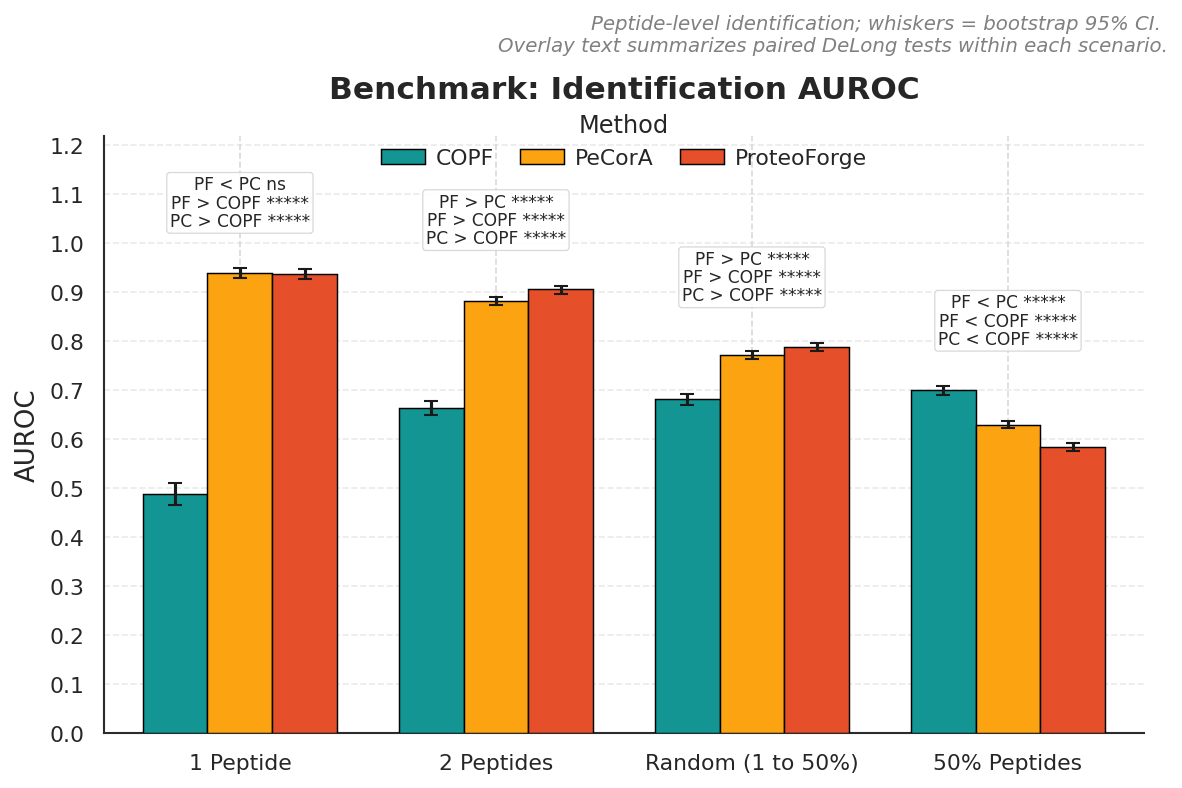

  Saved: id_auroc.png


In [6]:
plot_grouped_bars(
    id_summary, metric='auroc', ylabel='AUROC',
    title='Benchmark: Identification AUROC',
    methods=ID_METHOD_ORDER,
    filename='id_auroc.png',
    scenario_order=IDENTIFICATION_ORDER,
    scenario_labels=IDENTIFICATION_LABELS,
    ci_lower_col='auroc_ci_lower', ci_upper_col='auroc_ci_upper',
    ylim=(0, 1.22),
    note_text='Peptide-level identification; whiskers = bootstrap 95% CI. \nOverlay text summarizes paired DeLong tests within each scenario.',
    significance_df=id_delong,
    comparison_order=['ProteoForge vs PeCorA', 'ProteoForge vs COPF', 'PeCorA vs COPF'],
)
print('  Saved: id_auroc.png')

In [7]:
display_reference_table(
    'Identification Reference Table — AUROC and Paired DeLong Significance',
    build_metric_significance_table(
        id_summary,
        id_delong,
        IDENTIFICATION_ORDER,
        IDENTIFICATION_LABELS,
        ID_METHOD_ORDER,
        ['ProteoForge vs PeCorA', 'ProteoForge vs COPF', 'PeCorA vs COPF'],
        metric_col='auroc',
        ci_lower_col='auroc_ci_lower',
        ci_upper_col='auroc_ci_upper',
        metric_label='AUROC',
        delta_col='delta_auroc',
    )
)

### Identification Reference Table — AUROC and Paired DeLong Significance

,Scenario,COPF AUROC,PeCorA AUROC,ProteoForge AUROC,ProteoForge vs PeCorA,ProteoForge vs COPF,PeCorA vs COPF
0,1 Peptide,"0.489 [0.467, 0.511]","0.939 [0.930, 0.949]","0.937 [0.928, 0.947]",Δ=-0.002; q=3.52e-01; Bonf=1.00e+00; ns,Δ=+0.439; q=2.62e-269; Bonf=5.24e-269; *****,Δ=+0.443; q=1.15e-272; Bonf=1.15e-272; *****
1,2 Peptides,"0.664 [0.650, 0.678]","0.883 [0.873, 0.891]","0.906 [0.897, 0.914]",Δ=+0.024; q=3.36e-30; Bonf=1.01e-29; *****,Δ=+0.259; q=0.00e+00; Bonf=0.00e+00; *****,Δ=+0.240; q=2.31e-260; Bonf=4.63e-260; *****
2,Random (1 to 50%),"0.682 [0.671, 0.693]","0.772 [0.763, 0.780]","0.789 [0.780, 0.797]",Δ=+0.017; q=9.26e-17; Bonf=2.78e-16; *****,Δ=+0.114; q=6.66e-86; Bonf=6.66e-86; *****,Δ=+0.098; q=1.31e-62; Bonf=2.62e-62; *****
3,50% Peptides,"0.700 [0.691, 0.708]","0.630 [0.622, 0.638]","0.585 [0.576, 0.593]",Δ=-0.045; q=3.87e-103; Bonf=7.73e-103; *****,Δ=-0.117; q=7.83e-106; Bonf=7.83e-106; *****,Δ=-0.072; q=3.26e-43; Bonf=9.77e-43; *****


### Key Observations — Identification AUROC

- **ProteoForge** has the strongest peptide-level AUROC in the `1pep`, `2pep`, and `random` scenarios, where sparse or uneven perturbation coverage rewards sharper per-peptide ranking.
- **The 50% Peptides scenario is the major exception.** Here, AUROC reverses: COPF ranks highest, PeCorA is intermediate, and ProteoForge is lowest, so the benchmark is not monotonic with increasing peptide coverage.
- The DeLong overlay printed directly above each bar cluster now summarizes the paired AUROC ranking inside the same scenario. For example, the `1pep` overlay shows `PF < PeCorA` as non-significant, while both peptide-centric methods remain decisively above COPF.
- This reversal does **not** imply that ProteoForge is uniformly worse at 50% coverage: at the matched FPR = 5% operating point, ProteoForge still reaches higher sensitivity than PeCorA, showing that AUROC and fixed-operating-point performance are answering different questions.

---

# Part 2: Identification — Best MCC

**Question:** What is the best achievable classification balance (sensitivity × specificity) at the optimal threshold?

MCC ranges from −1 to +1 and accounts for all four cells of the confusion matrix, making it robust to class imbalance. The "best MCC" is the maximum MCC across a fine threshold grid. A method with high AUROC but low best MCC has good ranking but poor separability at any single threshold. The overlays in this section summarize paired permutation tests for those best-threshold MCC gaps within each scenario.

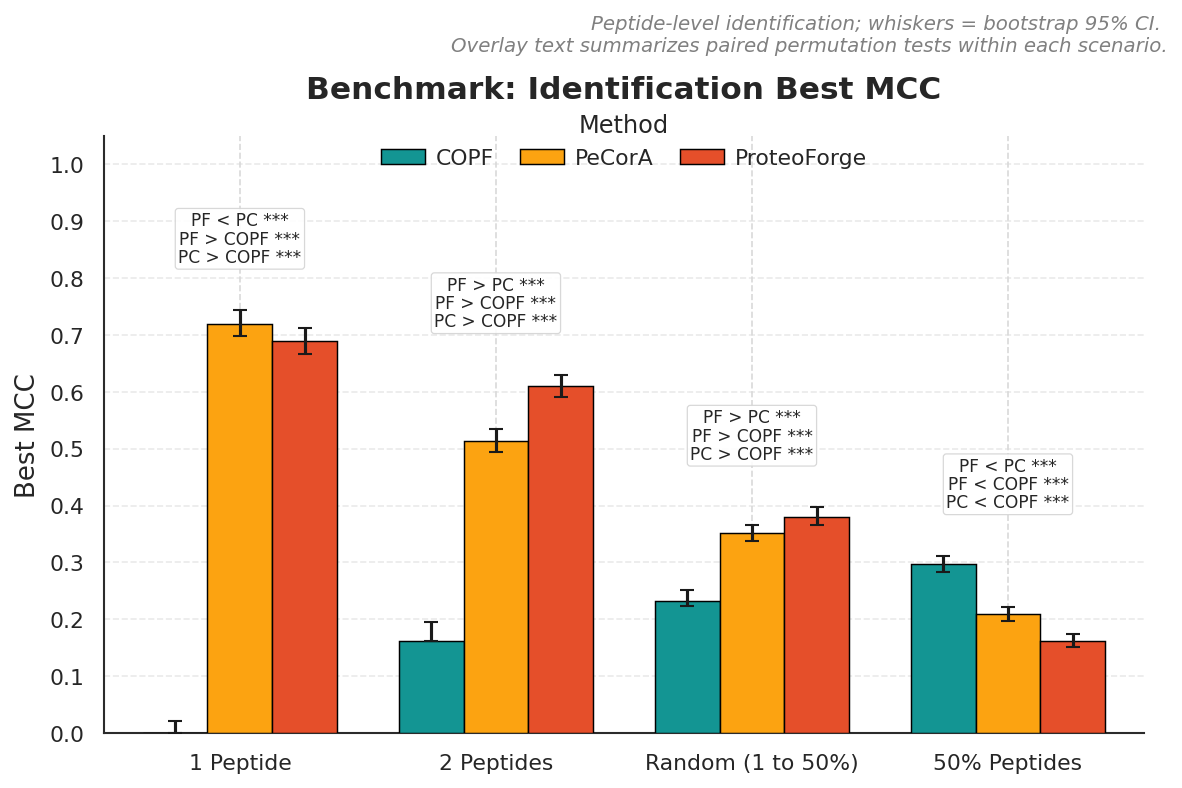

  Saved: id_best_mcc.png


In [8]:
plot_grouped_bars(
    id_summary, metric='best_mcc', ylabel='Best MCC',
    title='Benchmark: Identification Best MCC',
    methods=ID_METHOD_ORDER,
    filename='id_best_mcc.png',
    scenario_order=IDENTIFICATION_ORDER,
    scenario_labels=IDENTIFICATION_LABELS,
    ci_lower_col='best_mcc_ci_lower', ci_upper_col='best_mcc_ci_upper',
    note_text='Peptide-level identification; whiskers = bootstrap 95% CI. \nOverlay text summarizes paired permutation tests within each scenario.',
    significance_df=id_best_mcc_tests,
    comparison_order=['ProteoForge vs PeCorA', 'ProteoForge vs COPF', 'PeCorA vs COPF'],
    delta_col='delta_value',
)
print('  Saved: id_best_mcc.png')

In [9]:
display_reference_table(
    'Identification Reference Table — Best MCC and Paired Permutation Significance',
    build_metric_significance_table(
        id_summary,
        id_best_mcc_tests,
        IDENTIFICATION_ORDER,
        IDENTIFICATION_LABELS,
        ID_METHOD_ORDER,
        ['ProteoForge vs PeCorA', 'ProteoForge vs COPF', 'PeCorA vs COPF'],
        metric_col='best_mcc',
        ci_lower_col='best_mcc_ci_lower',
        ci_upper_col='best_mcc_ci_upper',
        metric_label='Best MCC',
        delta_col='delta_value',
    )
)

### Identification Reference Table — Best MCC and Paired Permutation Significance

,Scenario,COPF Best MCC,PeCorA Best MCC,ProteoForge Best MCC,ProteoForge vs PeCorA,ProteoForge vs COPF,PeCorA vs COPF
0,1 Peptide,"0.000 [0.004, 0.021]","0.719 [0.698, 0.743]","0.689 [0.666, 0.712]",Δ=-0.030; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.646; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.693; q=9.99e-04; Bonf=3.00e-03; ***
1,2 Peptides,"0.162 [0.165, 0.195]","0.513 [0.494, 0.534]","0.609 [0.591, 0.630]",Δ=+0.096; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.471; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.374; q=9.99e-04; Bonf=3.00e-03; ***
2,Random (1 to 50%),"0.232 [0.223, 0.252]","0.352 [0.338, 0.365]","0.379 [0.366, 0.397]",Δ=+0.028; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.156; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.129; q=9.99e-04; Bonf=3.00e-03; ***
3,50% Peptides,"0.298 [0.284, 0.311]","0.210 [0.198, 0.222]","0.162 [0.151, 0.175]",Δ=-0.048; q=9.99e-04; Bonf=3.00e-03; ***,Δ=-0.135; q=9.99e-04; Bonf=3.00e-03; ***,Δ=-0.088; q=9.99e-04; Bonf=3.00e-03; ***


---

# Part 3: Identification — Sensitivity at FPR = 5%

**Question:** At a practical false-positive budget, how sensitive is each method at the peptide level?

This is the most operationally relevant metric. All methods are evaluated at the threshold that yields a false-positive rate of 5%, enabling a direct apples-to-apples sensitivity comparison. Specificity is necessarily close to 0.95 by construction and is reported in the summary tables below. The overlays in this section summarize paired permutation tests on matched-FPR sensitivity within each scenario.

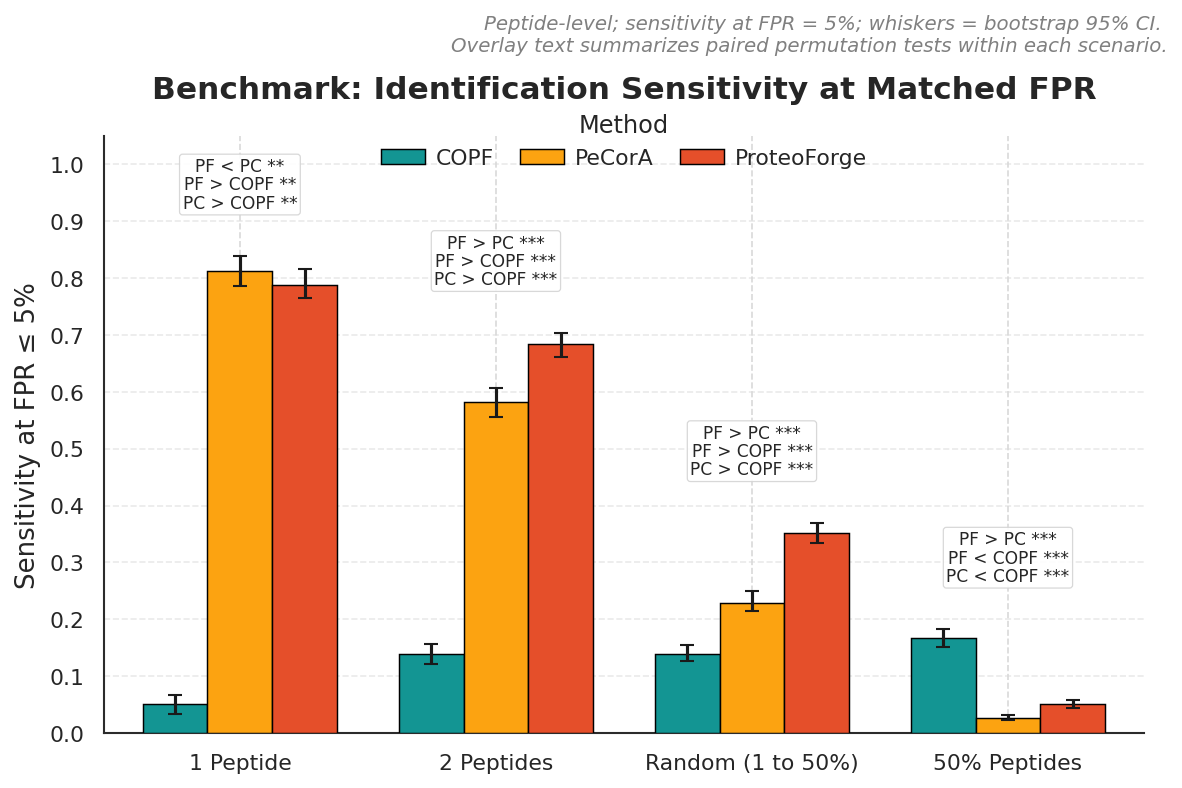

  Saved: id_sensitivity.png


In [10]:
plot_grouped_bars(
    id_operating, metric='matched_sensitivity', ylabel='Sensitivity at FPR ≤ 5%',
    title='Benchmark: Identification Sensitivity at Matched FPR',
    methods=ID_METHOD_ORDER,
    filename='id_sensitivity.png',
    scenario_order=IDENTIFICATION_ORDER,
    scenario_labels=IDENTIFICATION_LABELS,
    ci_lower_col='matched_sensitivity_ci_lower',
    ci_upper_col='matched_sensitivity_ci_upper',
    note_text='Peptide-level; sensitivity at FPR = 5%; whiskers = bootstrap 95% CI. \nOverlay text summarizes paired permutation tests within each scenario.',
    significance_df=id_matched_sens_tests,
    comparison_order=['ProteoForge vs PeCorA', 'ProteoForge vs COPF', 'PeCorA vs COPF'],
    delta_col='delta_value',
)
print('  Saved: id_sensitivity.png')

> **Interpretation note.** Specificity is necessarily close to $1 - 0.05 = 0.95$ whenever the realized FPR is near the target. Sensitivity is interpolated from the ROC curve at FPR = 5%, whereas specificity and precision are evaluated at the nearest realized threshold whose empirical FPR does not exceed 5%. Methods landing at a more conservative realized FPR can appear slightly better on specificity and precision, typically in exchange for lower sensitivity.

In [11]:
display_reference_table(
    'Identification Reference Table — Matched FPR Operating Point and Paired Permutation Significance',
    build_operating_significance_table(
        id_operating,
        id_matched_sens_tests,
        IDENTIFICATION_ORDER,
        IDENTIFICATION_LABELS,
        ['ProteoForge vs PeCorA', 'ProteoForge vs COPF', 'PeCorA vs COPF'],
    )
)

### Identification Reference Table — Matched FPR Operating Point and Paired Permutation Significance

,Scenario,method,Sensitivity (95% CI),Specificity (95% CI),Precision (95% CI),Actual FPR,Threshold,ProteoForge vs PeCorA,ProteoForge vs COPF,PeCorA vs COPF
0,1 Peptide,COPF,"0.051 [0.034, 0.067]","0.950 [0.950, 0.952]","0.036 [0.024, 0.048]",0.050,5.31e-02,Δ=-0.024; q=5.00e-03; Bonf=1.50e-02; **,Δ=+0.722; q=1.50e-03; Bonf=3.00e-03; **,Δ=+0.750; q=1.50e-03; Bonf=3.00e-03; **
1,1 Peptide,PeCorA,"0.813 [0.786, 0.838]","0.950 [0.950, 0.950]","0.434 [0.415, 0.450]",0.050,1.51e-04,Δ=-0.024; q=5.00e-03; Bonf=1.50e-02; **,Δ=+0.722; q=1.50e-03; Bonf=3.00e-03; **,Δ=+0.750; q=1.50e-03; Bonf=3.00e-03; **
2,1 Peptide,ProteoForge,"0.788 [0.765, 0.816]","0.952 [0.950, 0.950]","0.436 [0.409, 0.445]",0.048,1.51e-06,Δ=-0.024; q=5.00e-03; Bonf=1.50e-02; **,Δ=+0.722; q=1.50e-03; Bonf=3.00e-03; **,Δ=+0.750; q=1.50e-03; Bonf=3.00e-03; **
3,2 Peptides,COPF,"0.139 [0.122, 0.157]","0.951 [0.950, 0.952]","0.213 [0.189, 0.234]",0.049,4.96e-06,Δ=+0.102; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.591; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.493; q=9.99e-04; Bonf=3.00e-03; ***
4,2 Peptides,PeCorA,"0.582 [0.556, 0.606]","0.950 [0.950, 0.950]","0.535 [0.519, 0.550]",0.050,5.76e-05,Δ=+0.102; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.591; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.493; q=9.99e-04; Bonf=3.00e-03; ***
5,2 Peptides,ProteoForge,"0.684 [0.661, 0.704]","0.950 [0.950, 0.950]","0.576 [0.561, 0.589]",0.050,2.35e-07,Δ=+0.102; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.591; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.493; q=9.99e-04; Bonf=3.00e-03; ***
6,Random (1 to 50%),COPF,"0.139 [0.127, 0.154]","0.950 [0.950, 0.951]","0.358 [0.335, 0.383]",0.050,1.28e-05,Δ=+0.125; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.230; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.105; q=9.99e-04; Bonf=3.00e-03; ***
7,Random (1 to 50%),PeCorA,"0.228 [0.214, 0.249]","0.950 [0.950, 0.950]","0.471 [0.454, 0.493]",0.050,1.58e-05,Δ=+0.125; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.230; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.105; q=9.99e-04; Bonf=3.00e-03; ***
8,Random (1 to 50%),ProteoForge,"0.352 [0.334, 0.370]","0.950 [0.950, 0.950]","0.579 [0.563, 0.595]",0.050,2.57e-09,Δ=+0.125; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.230; q=9.99e-04; Bonf=3.00e-03; ***,Δ=+0.105; q=9.99e-04; Bonf=3.00e-03; ***
9,50% Peptides,COPF,"0.167 [0.152, 0.182]","0.951 [0.950, 0.951]","0.524 [0.499, 0.547]",0.049,4.25e-05,Δ=+0.024; q=9.99e-04; Bonf=3.00e-03; ***,Δ=-0.117; q=9.99e-04; Bonf=3.00e-03; ***,Δ=-0.142; q=9.99e-04; Bonf=3.00e-03; ***


---

# Part 4: Identification — Paired DeLong AUROC Effect Sizes

**Question:** Once significance is already overlaid on the AUROC bars, what additional information do the paired DeLong effect-size plots add?

This section reframes the DeLong results as **effect-size views**. The AUROC bar plot above already shows which within-scenario method comparisons are significant. Here, the delta-AUROC panels focus on **direction and magnitude**: how far each paired AUROC difference sits from zero, whether the sign flips across scenarios, and how the effect-size story complements the threshold-dependent MCC and matched-FPR summaries shown earlier.

## Identification — Paired DeLong AUROC Plot

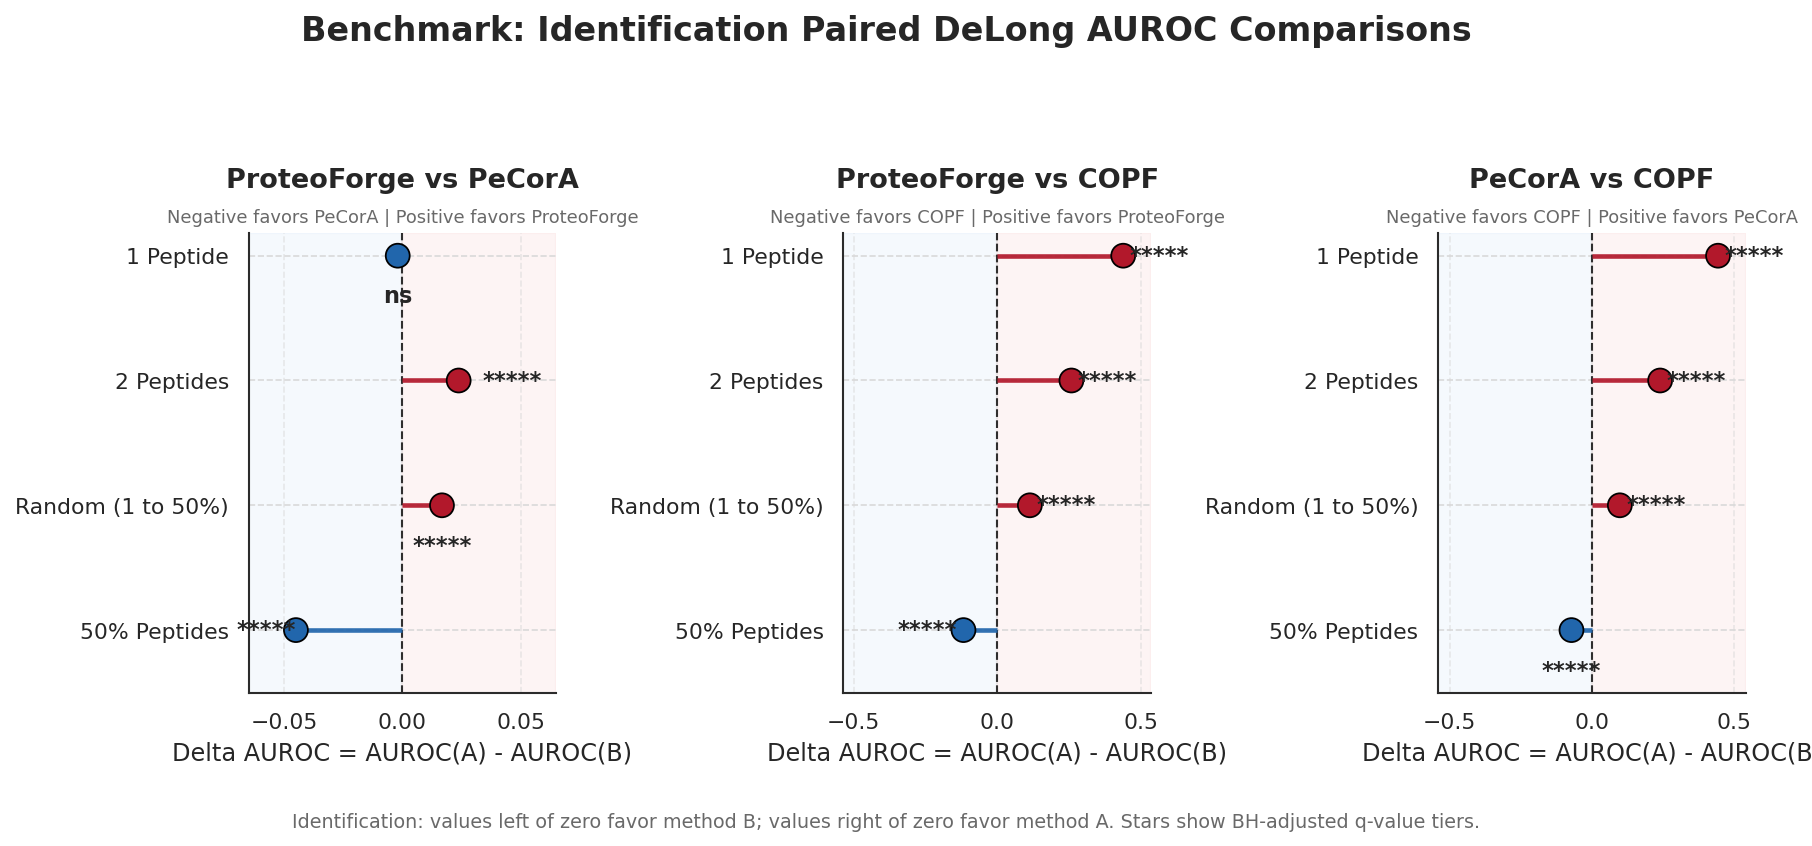

  Saved: id_delong_delta_plot.png


### Interpretation — Identification DeLong Results
- The AUROC bar plot above already overlays the paired significance result within each scenario, while the panels here isolate the signed effect size.
- The paired DeLong comparison uses the same peptide-level evaluation items within each scenario, so the AUROC differences shown here are not driven by mismatched test sets.
- The benchmark now reports both BH-adjusted q-values and Bonferroni-adjusted p-values in the accompanying table, so the scale of the AUROC evidence can be checked under two standard multiplicity controls.
- The strongest reversal appears in the `50% Peptides` scenario, where both `ProteoForge vs PeCorA` and `ProteoForge vs COPF` turn negative, indicating weaker threshold-free ranking by ProteoForge in that dense-perturbation setting.
- This does not contradict the matched-FPR sensitivity result: at `50% Peptides`, ProteoForge still detects more true perturbed peptides than PeCorA at FPR = 5%, which shows that global ranking quality and a fixed operating point are not interchangeable summaries.


## Identification — Paired DeLong AUROC Table

,Scenario,Comparison,Items,Method A AUROC,Method B AUROC,Delta AUROC,Z,P,BH q,Bonf. p,Signif.
0,1 Peptide,PeCorA vs COPF,22012,0.932,0.489,+0.443,35.312,3.84e-273,1.15e-272,1.15e-272,*****
1,1 Peptide,ProteoForge vs COPF,22013,0.929,0.489,+0.439,35.073,1.75e-269,2.62e-269,5.24e-269,*****
2,1 Peptide,ProteoForge vs PeCorA,22012,0.937,0.939,-0.002,-0.932,3.52e-01,3.52e-01,1.00e+00,ns
3,2 Peptides,PeCorA vs COPF,22020,0.904,0.664,+0.240,34.481,1.54e-260,2.31e-260,4.63e-260,*****
4,2 Peptides,ProteoForge vs COPF,22021,0.923,0.664,+0.259,39.101,0.00e+00,0.00e+00,0.00e+00,*****
5,2 Peptides,ProteoForge vs PeCorA,22020,0.906,0.882,+0.024,11.419,3.36e-30,3.36e-30,1.01e-29,*****
6,Random (1 to 50%),PeCorA vs COPF,22026,0.780,0.682,+0.098,16.724,8.74e-63,1.31e-62,2.62e-62,*****
7,Random (1 to 50%),ProteoForge vs COPF,22027,0.796,0.682,+0.114,19.699,2.22e-86,6.66e-86,6.66e-86,*****
8,Random (1 to 50%),ProteoForge vs PeCorA,22026,0.788,0.771,+0.017,8.314,9.26e-17,9.26e-17,2.78e-16,*****
9,50% Peptides,PeCorA vs COPF,22035,0.628,0.701,-0.072,-13.782,3.26e-43,3.26e-43,9.77e-43,*****


In [12]:
def plot_delong_delta(df, scenario_order, scenario_labels, title, filename, comparison_order, level_label):
    frame = df.copy()
    frame['scenario'] = pd.Categorical(frame['scenario'], categories=scenario_order, ordered=True)
    frame['Comparison'] = frame['method_a'] + ' vs ' + frame['method_b']
    frame['Comparison'] = pd.Categorical(frame['Comparison'], categories=comparison_order, ordered=True)
    frame['Scenario'] = frame['scenario'].map(scenario_labels)
    frame['Stars'] = frame['pvalue_bh'].map(significance_stars)
    frame = frame.sort_values(['Comparison', 'scenario']).reset_index(drop=True)

    comparisons = [comp for comp in comparison_order if comp in frame['Comparison'].astype(str).unique()]
    fig, axes = plt.subplots(
        1, len(comparisons),
        figsize=(4.1 * len(comparisons), max(4.2, 0.9 * len(scenario_order) + 2.1)),
        sharex=False,
    )
    if len(comparisons) == 1:
        axes = [axes]

    for ax, comparison in zip(axes, comparisons):
        sub = frame[frame['Comparison'] == comparison].copy()
        sub = sub.sort_values('scenario').reset_index(drop=True)
        method_a, method_b = comparison.split(' vs ')
        y_pos = np.arange(len(sub))
        colors = ['#b2182b' if value > 0 else '#2166ac' for value in sub['delta_auroc']]
        local_max = max(0.03, float(sub['delta_auroc'].abs().max()))
        x_padding = max(0.02, local_max * 0.22)
        x_limits = (-local_max - x_padding, local_max + x_padding)

        ax.axvspan(x_limits[0], 0.0, color='#e8f1fb', alpha=0.42, zorder=0)
        ax.axvspan(0.0, x_limits[1], color='#fbe7e7', alpha=0.42, zorder=0)
        ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.hlines(y=y_pos, xmin=0, xmax=sub['delta_auroc'], color=colors, linewidth=2.2, alpha=0.92)
        ax.scatter(sub['delta_auroc'], y_pos, s=132, color=colors, edgecolor='black', linewidth=0.85, zorder=3)

        star_offset = max(0.010, local_max * 0.05)
        star_guard = max(0.020, local_max * 0.10)
        left_text_x = x_limits[0] + star_guard
        right_text_x = x_limits[1] - star_guard
        near_zero_threshold = max(0.02, local_max * 0.20)

        for idx, row in sub.iterrows():
            if abs(row['delta_auroc']) <= near_zero_threshold:
                ax.annotate(
                    row['Stars'],
                    xy=(row['delta_auroc'], idx),
                    xytext=(0, -14),
                    textcoords='offset points',
                    ha='center',
                    va='top',
                    fontsize=10.8,
                    fontweight='bold',
                    zorder=4,
                )
                continue

            if row['delta_auroc'] >= 0:
                x_text = min(row['delta_auroc'] + star_offset, right_text_x)
                ha = 'left'
            else:
                x_text = max(row['delta_auroc'] - star_offset, left_text_x)
                ha = 'right'
            ax.text(
                x_text, idx, row['Stars'],
                va='center', ha=ha, fontsize=10.8, fontweight='bold', zorder=4
            )

        ax.set_xlim(*x_limits)
        ax.set_ylim(len(sub) - 0.5, -0.18)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(sub['Scenario'])
        ax.set_title(comparison, fontsize=13, pad=22)
        ax.set_xlabel('Delta AUROC = AUROC(A) - AUROC(B)', fontsize=11.5)
        ax.text(
            0.5, 1.015,
            f'Negative favors {method_b} | Positive favors {method_a}',
            transform=ax.transAxes, ha='center', va='bottom', fontsize=8.6, color='dimgray'
        )
        style_axis(ax, grid_axis='x')

    axes[0].set_ylabel('')
    fig.suptitle(title, fontsize=16, fontweight='semibold', y=0.975)
    fig.text(
        0.5, 0.02,
        f'{level_label}: values left of zero favor method B; values right of zero favor method A. Stars show BH-adjusted q-value tiers.',
        ha='center', va='bottom', fontsize=9.2, color='dimgray'
    )
    fig.tight_layout(rect=(0.015, 0.07, 0.995, 0.89))
    save_fig(fig, filename)
    plt.show()
    print(f'  Saved: {filename}')


display(Markdown('## Identification — Paired DeLong AUROC Plot'))
plot_delong_delta(
    id_delong,
    IDENTIFICATION_ORDER,
    IDENTIFICATION_LABELS,
    title='Benchmark: Identification Paired DeLong AUROC Comparisons',
    filename='id_delong_delta_plot.png',
    comparison_order=['ProteoForge vs PeCorA', 'ProteoForge vs COPF', 'PeCorA vs COPF'],
    level_label='Identification',
)

display(Markdown("""### Interpretation — Identification DeLong Results
- The AUROC bar plot above already overlays the paired significance result within each scenario, while the panels here isolate the signed effect size.
- The paired DeLong comparison uses the same peptide-level evaluation items within each scenario, so the AUROC differences shown here are not driven by mismatched test sets.
- The benchmark now reports both BH-adjusted q-values and Bonferroni-adjusted p-values in the accompanying table, so the scale of the AUROC evidence can be checked under two standard multiplicity controls.
- The strongest reversal appears in the `50% Peptides` scenario, where both `ProteoForge vs PeCorA` and `ProteoForge vs COPF` turn negative, indicating weaker threshold-free ranking by ProteoForge in that dense-perturbation setting.
- This does not contradict the matched-FPR sensitivity result: at `50% Peptides`, ProteoForge still detects more true perturbed peptides than PeCorA at FPR = 5%, which shows that global ranking quality and a fixed operating point are not interchangeable summaries.
"""))

display(Markdown('## Identification — Paired DeLong AUROC Table'))
display(build_delong_table(id_delong, IDENTIFICATION_ORDER, IDENTIFICATION_LABELS))

---

# Part 5: Grouping — Discriminative Power (AUROC)

**Question:** How well does each method's protein-level score separate proteins that truly harbor proteoforms from those that do not?

Grouping evaluates classification at the **protein level**: a protein is a true positive if it contains at least one perturbed peptide. PeCorA is excluded because it produces no grouping output. Only ProteoForge and COPF are compared. The `1pep` scenario is excluded at the grouping level because a single perturbed peptide is too sparse for meaningful protein-level detection.

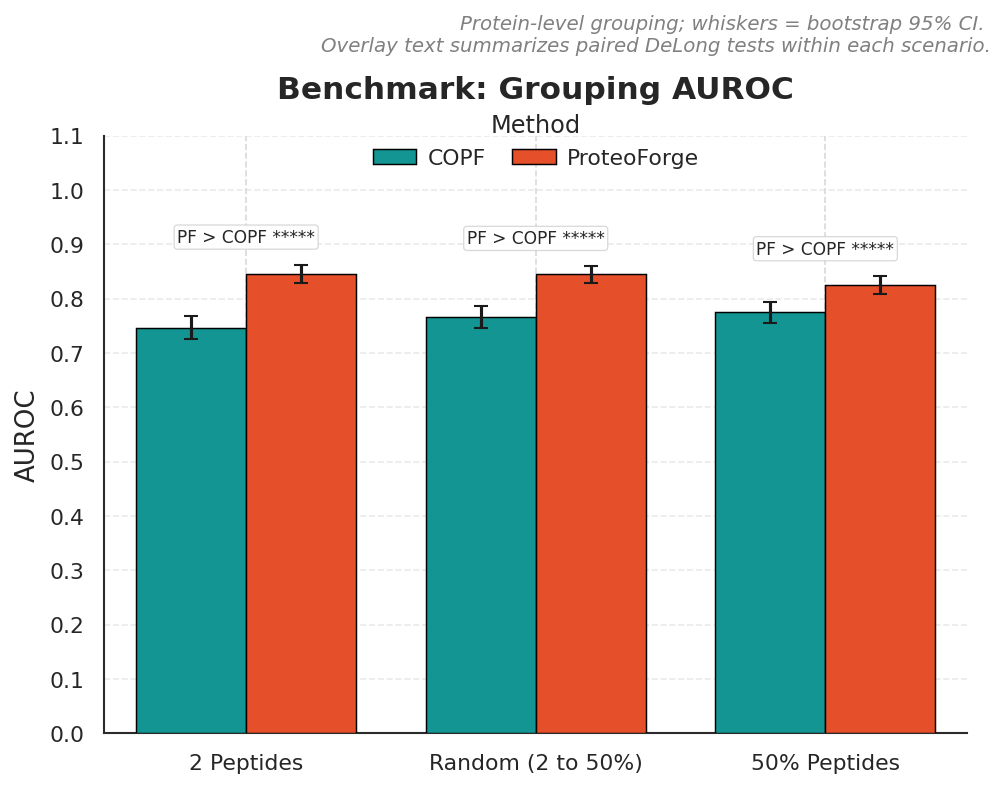

  Saved: grp_auroc.png


In [13]:
plot_grouped_bars(
    grp_summary, metric='auroc', ylabel='AUROC',
    title='Benchmark: Grouping AUROC',
    methods=GRP_METHOD_ORDER,
    filename='grp_auroc.png',
    scenario_order=GROUPING_ORDER,
    scenario_labels=GROUPING_LABELS,
    ci_lower_col='auroc_ci_lower', ci_upper_col='auroc_ci_upper',
    ylim=(0, 1.10),
    note_text='Protein-level grouping; whiskers = bootstrap 95% CI. \nOverlay text summarizes paired DeLong tests within each scenario.',
    significance_df=grp_delong,
    comparison_order=['ProteoForge vs COPF'],
)
print('  Saved: grp_auroc.png')

In [14]:
display_reference_table(
    'Grouping Reference Table — AUROC and Paired DeLong Significance',
    build_metric_significance_table(
        grp_summary,
        grp_delong,
        GROUPING_ORDER,
        GROUPING_LABELS,
        GRP_METHOD_ORDER,
        ['ProteoForge vs COPF'],
        metric_col='auroc',
        ci_lower_col='auroc_ci_lower',
        ci_upper_col='auroc_ci_upper',
        metric_label='AUROC',
        delta_col='delta_auroc',
    )
)

### Grouping Reference Table — AUROC and Paired DeLong Significance

,Scenario,COPF AUROC,ProteoForge AUROC,ProteoForge vs COPF
0,2 Peptides,"0.747 [0.726, 0.768]","0.846 [0.828, 0.863]",Δ=+0.099; q=1.80e-23; Bonf=1.80e-23; *****
1,Random (2 to 50%),"0.766 [0.746, 0.787]","0.845 [0.829, 0.860]",Δ=+0.079; q=8.17e-16; Bonf=8.17e-16; *****
2,50% Peptides,"0.774 [0.755, 0.795]","0.825 [0.808, 0.841]",Δ=+0.051; q=7.22e-07; Bonf=7.22e-07; *****


### Key Observations — Grouping AUROC

- **ProteoForge** substantially outperforms COPF in grouping AUROC across all three scenarios, confirming its advantage in protein-level proteoform detection.
- The overlay text above each bar cluster reports the paired DeLong result in the same scenario, so the visual ranking and the inferential result can be read together rather than in separate panels.
- The gap is widest for the 2 Peptides condition and narrows toward 50% coverage, but the direction stays stable in both the AUROC bars and the paired significance overlay.

---

# Part 6: Grouping — Paired DeLong AUROC Effect Size

**Question:** After the AUROC bar plot already reports the paired significance outcome, what does the dedicated DeLong panel add at the grouping level?

This panel isolates the **effect size** for `ProteoForge vs COPF`. The overlay on the grouping AUROC bars already states that the comparison is significant in every scenario; the delta-AUROC plot below makes the shrinking magnitude of that advantage easier to judge across scenarios.

## Grouping — Paired DeLong AUROC Plot

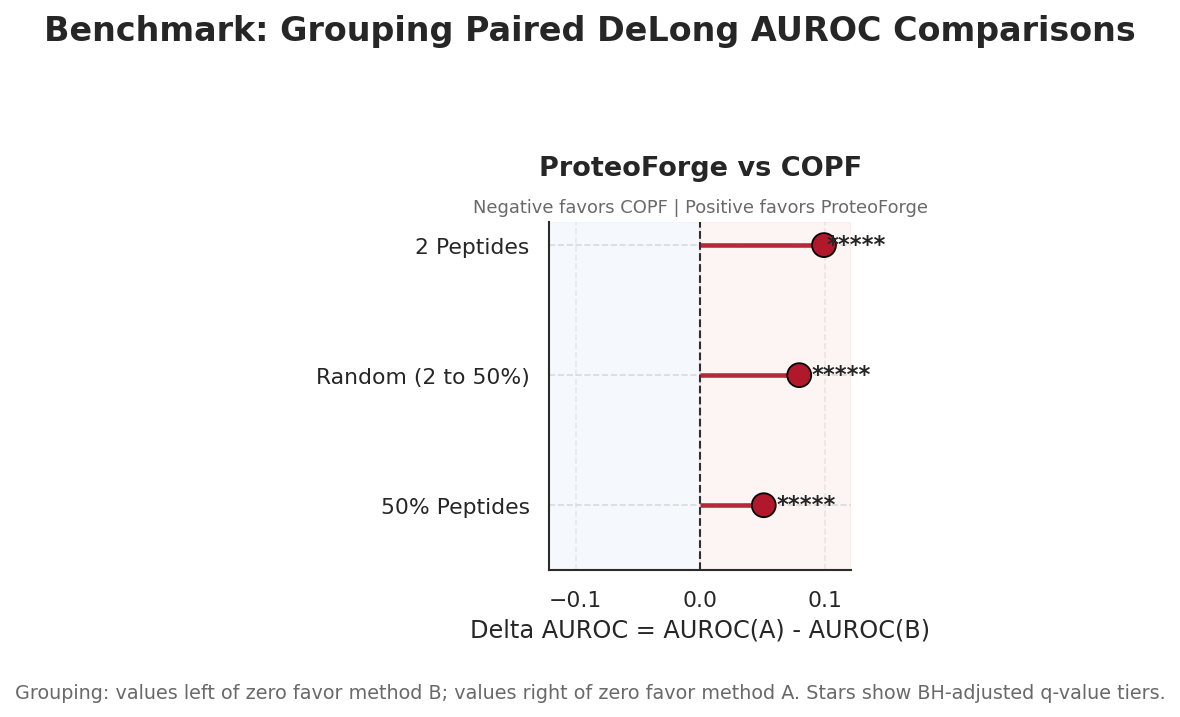

  Saved: grp_delong_delta_plot.png


### Interpretation — Grouping DeLong Results
- The grouping comparison is simpler because only `ProteoForge vs COPF` is available at the protein level.
- All grouping deltas are positive, so ProteoForge has the stronger threshold-free ranking in every grouping scenario.
- Because each grouping scenario contains only one inferential comparison, the BH-adjusted q-value equals the raw p-value within that family; the Bonferroni-adjusted p-value therefore reduces to the same single-comparison value as well.
- The effect size shrinks from `2 Peptides` to `50% Peptides`, but the direction stays consistent, which supports the robustness of the grouping advantage.


## Grouping — Paired DeLong AUROC Table

,Scenario,Comparison,Items,Method A AUROC,Method B AUROC,Delta AUROC,Z,P,BH q,Bonf. p,Signif.
0,2 Peptides,ProteoForge vs COPF,2217,0.846,0.747,+0.099,9.984,1.80e-23,1.80e-23,1.80e-23,*****
1,Random (2 to 50%),ProteoForge vs COPF,2217,0.845,0.766,+0.079,8.052,8.17e-16,8.17e-16,8.17e-16,*****
2,50% Peptides,ProteoForge vs COPF,2217,0.825,0.774,+0.051,4.955,7.22e-07,7.22e-07,7.22e-07,*****


In [15]:
display(Markdown('## Grouping — Paired DeLong AUROC Plot'))
plot_delong_delta(
    grp_delong,
    GROUPING_ORDER,
    GROUPING_LABELS,
    title='Benchmark: Grouping Paired DeLong AUROC Comparisons',
    filename='grp_delong_delta_plot.png',
    comparison_order=['ProteoForge vs COPF'],
    level_label='Grouping',
)

display(Markdown("""### Interpretation — Grouping DeLong Results
- The grouping comparison is simpler because only `ProteoForge vs COPF` is available at the protein level.
- All grouping deltas are positive, so ProteoForge has the stronger threshold-free ranking in every grouping scenario.
- Because each grouping scenario contains only one inferential comparison, the BH-adjusted q-value equals the raw p-value within that family; the Bonferroni-adjusted p-value therefore reduces to the same single-comparison value as well.
- The effect size shrinks from `2 Peptides` to `50% Peptides`, but the direction stays consistent, which supports the robustness of the grouping advantage.
"""))

display(Markdown('## Grouping — Paired DeLong AUROC Table'))
display(build_delong_table(grp_delong, GROUPING_ORDER, GROUPING_LABELS))

---

# Part 7: Grouping — Best MCC

**Question:** How well can each method classify proteins as harboring proteoforms at the optimal threshold?

This section complements grouping AUROC with threshold-optimized classification quality. The overlay text summarizes paired permutation tests for Best MCC within each grouping scenario, so threshold-dependent gains can be read directly from the bar plot and the supporting table below.

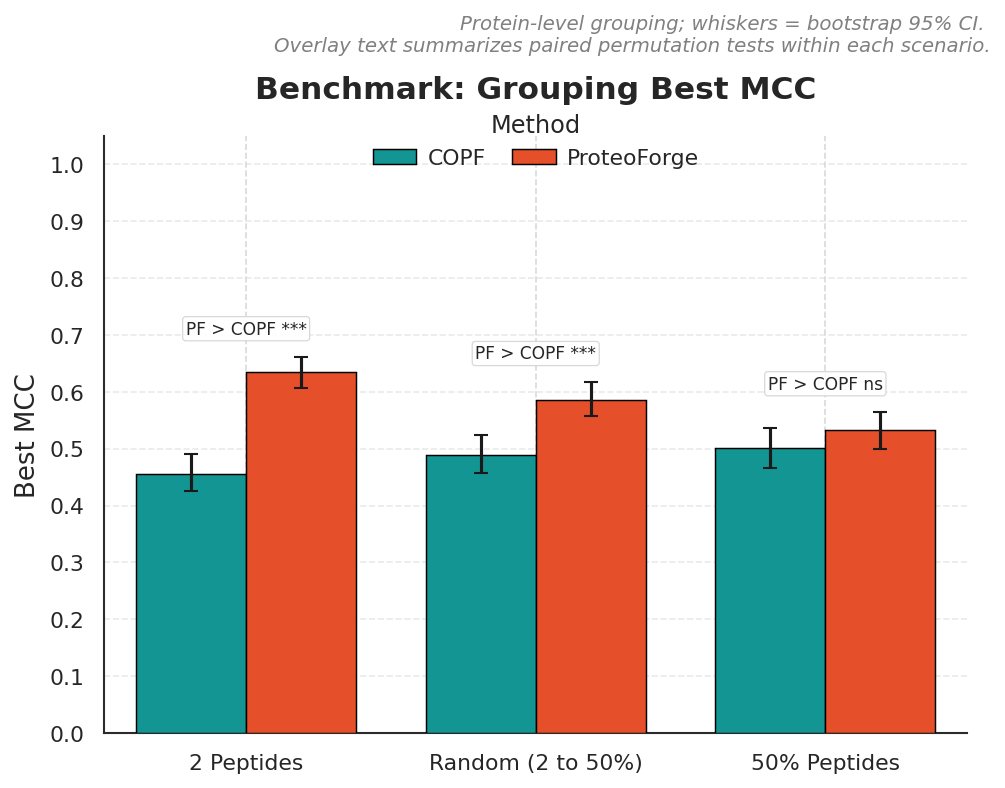

  Saved: grp_best_mcc.png


In [16]:
plot_grouped_bars(
    grp_summary, metric='best_mcc', ylabel='Best MCC',
    title='Benchmark: Grouping Best MCC',
    methods=GRP_METHOD_ORDER,
    filename='grp_best_mcc.png',
    scenario_order=GROUPING_ORDER,
    scenario_labels=GROUPING_LABELS,
    ci_lower_col='best_mcc_ci_lower', ci_upper_col='best_mcc_ci_upper',
    note_text='Protein-level grouping; whiskers = bootstrap 95% CI. \nOverlay text summarizes paired permutation tests within each scenario.',
    significance_df=grp_best_mcc_tests,
    comparison_order=['ProteoForge vs COPF'],
    delta_col='delta_value',
)
print('  Saved: grp_best_mcc.png')

In [17]:
display_reference_table(
    'Grouping Reference Table — Best MCC and Paired Permutation Significance',
    build_metric_significance_table(
        grp_summary,
        grp_best_mcc_tests,
        GROUPING_ORDER,
        GROUPING_LABELS,
        GRP_METHOD_ORDER,
        ['ProteoForge vs COPF'],
        metric_col='best_mcc',
        ci_lower_col='best_mcc_ci_lower',
        ci_upper_col='best_mcc_ci_upper',
        metric_label='Best MCC',
        delta_col='delta_value',
    )
)

### Grouping Reference Table — Best MCC and Paired Permutation Significance

,Scenario,COPF Best MCC,ProteoForge Best MCC,ProteoForge vs COPF
0,2 Peptides,"0.455 [0.426, 0.491]","0.634 [0.607, 0.661]",Δ=+0.179; q=9.99e-04; Bonf=9.99e-04; ***
1,Random (2 to 50%),"0.489 [0.457, 0.525]","0.585 [0.558, 0.617]",Δ=+0.096; q=9.99e-04; Bonf=9.99e-04; ***
2,50% Peptides,"0.501 [0.466, 0.536]","0.534 [0.499, 0.564]",Δ=+0.033; q=1.88e-01; Bonf=1.88e-01; ns


---

# Part 8: Grouping — Sensitivity at FPR = 5%

**Question:** At a controlled false-positive rate, which method detects more proteoform-harboring proteins in the benchmark dataset?

This section keeps the comparison on a common false-positive budget and now overlays the paired permutation result for matched-FPR sensitivity inside each scenario, so the operational effect size and its inferential support are reported together.

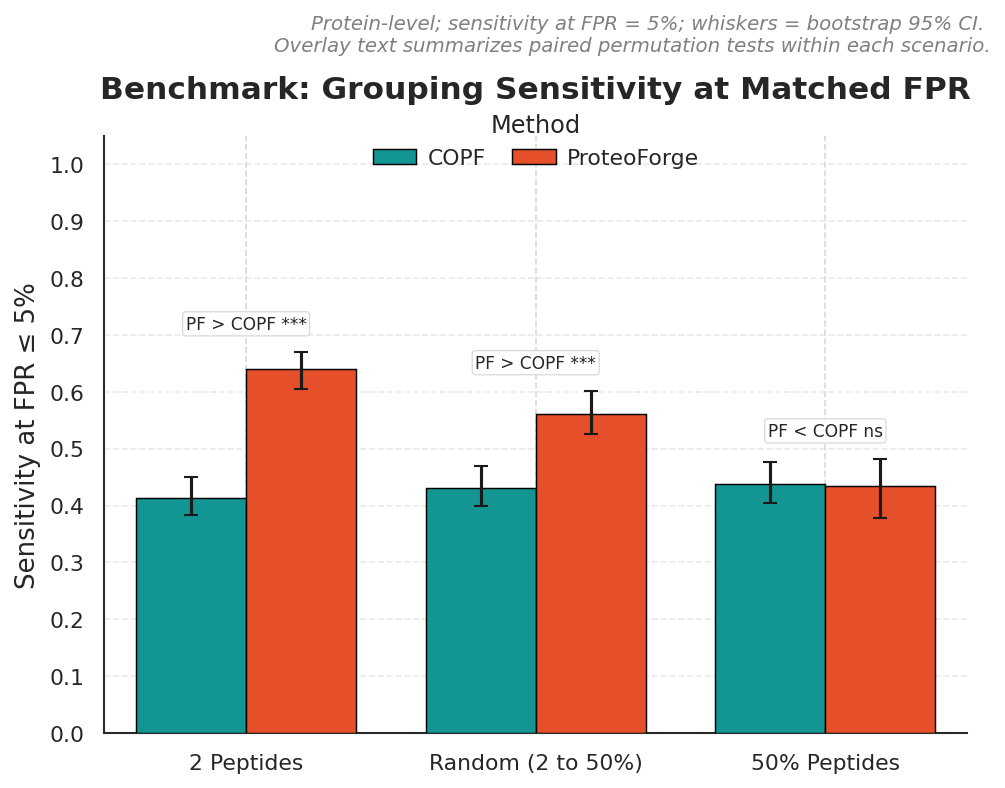

  Saved: grp_sensitivity.png


In [18]:
plot_grouped_bars(
    grp_operating, metric='matched_sensitivity', ylabel='Sensitivity at FPR ≤ 5%',
    title='Benchmark: Grouping Sensitivity at Matched FPR',
    methods=GRP_METHOD_ORDER,
    filename='grp_sensitivity.png',
    scenario_order=GROUPING_ORDER,
    scenario_labels=GROUPING_LABELS,
    ci_lower_col='matched_sensitivity_ci_lower',
    ci_upper_col='matched_sensitivity_ci_upper',
    note_text='Protein-level; sensitivity at FPR = 5%; whiskers = bootstrap 95% CI. \nOverlay text summarizes paired permutation tests within each scenario.',
    significance_df=grp_matched_sens_tests,
    comparison_order=['ProteoForge vs COPF'],
    delta_col='delta_value',
)
print('  Saved: grp_sensitivity.png')

In [19]:
display_reference_table(
    'Grouping Reference Table — Matched FPR Operating Point and Paired Permutation Significance',
    build_operating_significance_table(
        grp_operating,
        grp_matched_sens_tests,
        GROUPING_ORDER,
        GROUPING_LABELS,
        ['ProteoForge vs COPF'],
    )
)

### Grouping Reference Table — Matched FPR Operating Point and Paired Permutation Significance

,Scenario,method,Sensitivity (95% CI),Specificity (95% CI),Precision (95% CI),Actual FPR,Threshold,ProteoForge vs COPF
0,2 Peptides,COPF,"0.413 [0.383, 0.450]","0.988 [0.982, 0.994]","0.957 [0.936, 0.978]",0.012,1.00e-02,Δ=+0.227; q=9.99e-04; Bonf=9.99e-04; ***
1,2 Peptides,ProteoForge,"0.640 [0.606, 0.669]","0.956 [0.951, 0.970]","0.922 [0.910, 0.944]",0.044,1.00e-06,Δ=+0.227; q=9.99e-04; Bonf=9.99e-04; ***
2,Random (2 to 50%),COPF,"0.431 [0.399, 0.469]","0.988 [0.982, 0.994]","0.958 [0.936, 0.978]",0.012,1.00e-02,Δ=+0.131; q=9.99e-04; Bonf=9.99e-04; ***
3,Random (2 to 50%),ProteoForge,"0.562 [0.526, 0.601]","0.968 [0.951, 0.974]","0.931 [0.901, 0.943]",0.032,1.00e-07,Δ=+0.131; q=9.99e-04; Bonf=9.99e-04; ***
4,50% Peptides,COPF,"0.437 [0.404, 0.476]","0.988 [0.982, 0.994]","0.958 [0.936, 0.978]",0.012,1.00e-02,Δ=-0.003; q=9.46e-01; Bonf=9.46e-01; ns
5,50% Peptides,ProteoForge,"0.435 [0.378, 0.481]","0.962 [0.950, 0.968]","0.893 [0.863, 0.910]",0.038,1.00e-07,Δ=-0.003; q=9.46e-01; Bonf=9.46e-01; ns


---

# Part 9: Aggregate Summary and Audit

The remaining tables consolidate cross-scenario behavior and provide an audit of how closely the matched operating points track the intended 5% false-positive target. Detailed identification and grouping reference tables are now shown directly within their respective sections above.

In [20]:
# ── Aggregate Summary ──────────────────────────────────────────────────────────
def aggregate_summary(df, level_label):
    """Per-method mean/median/range of AUROC and Best MCC across scenarios."""
    agg = (
        df.groupby('method')
        .agg(
            n_scenarios=('scenario', 'nunique'),
            AUROC_mean=('auroc', 'mean'),
            AUROC_median=('auroc', 'median'),
            AUROC_min=('auroc', 'min'),
            AUROC_max=('auroc', 'max'),
            MCC_mean=('best_mcc', 'mean'),
            MCC_median=('best_mcc', 'median'),
        )
        .reset_index()
        .sort_values('method')
    )
    return agg


display(Markdown('## Aggregate Summary — Identification'))
display(
    aggregate_summary(id_summary, 'Identification').style
    .format({col: '{:.3f}' for col in ['AUROC_mean', 'AUROC_median', 'AUROC_min',
                                        'AUROC_max', 'MCC_mean', 'MCC_median']})
    .set_caption('Mean/median AUROC and Best MCC across benchmark identification scenarios')
)

display(Markdown('## Aggregate Summary — Grouping'))
display(
    aggregate_summary(grp_summary, 'Grouping').style
    .format({col: '{:.3f}' for col in ['AUROC_mean', 'AUROC_median', 'AUROC_min',
                                        'AUROC_max', 'MCC_mean', 'MCC_median']})
    .set_caption('Mean/median AUROC and Best MCC across benchmark grouping scenarios')
)

# ── FPR Audit ─────────────────────────────────────────────────────────────────
audit = pd.concat([
    id_operating.assign(level='Identification'),
    grp_operating.assign(level='Grouping'),
], ignore_index=True)
audit['abs_delta'] = (audit['matched_actual_fpr'] - audit['matched_fpr_target']).abs()

audit_summary = (
    audit.groupby('level', as_index=False)
    .agg(rows=('method', 'size'),
         max_abs_delta=('abs_delta', 'max'),
         median_abs_delta=('abs_delta', 'median'))
    .sort_values('level')
)

display(Markdown('## FPR Target Audit'))
display(audit_summary.style.set_caption(
    'Deviation of realized FPR from the 5% target across all operating-point evaluations'))

## Aggregate Summary — Identification

,method,n_scenarios,AUROC_mean,AUROC_median,AUROC_min,AUROC_max,MCC_mean,MCC_median
0,COPF,4,0.634,0.673,0.489,0.700,0.173,0.197
1,PeCorA,4,0.806,0.827,0.630,0.939,0.449,0.432
2,ProteoForge,4,0.804,0.847,0.585,0.937,0.460,0.494


## Aggregate Summary — Grouping

,method,n_scenarios,AUROC_mean,AUROC_median,AUROC_min,AUROC_max,MCC_mean,MCC_median
0,COPF,3,0.762,0.766,0.747,0.774,0.481,0.489
1,ProteoForge,3,0.839,0.845,0.825,0.846,0.584,0.585


## FPR Target Audit

,level,rows,max_abs_delta,median_abs_delta
0,Grouping,6,0.037675,0.027814
1,Identification,12,0.002040,0.000147


In [21]:
# ── Output Inventory ──────────────────────────────────────────────────────────
artifact_manifest = pd.DataFrame([
    {'Artifact': 'Identification summary',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'identification_summary.csv')),
     'Rows': len(id_summary)},
    {'Artifact': 'Grouping summary',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'grouping_summary.csv')),
     'Rows': len(grp_summary)},
    {'Artifact': 'Identification operating point',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'identification_operating_point_table.csv')),
     'Rows': len(id_operating)},
    {'Artifact': 'Grouping operating point',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'grouping_operating_point_table.csv')),
     'Rows': len(grp_operating)},
    {'Artifact': 'Identification DeLong table',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'identification_delong.csv')),
     'Rows': len(id_delong)},
    {'Artifact': 'Grouping DeLong table',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'grouping_delong.csv')),
     'Rows': len(grp_delong)},
    {'Artifact': 'Identification Best MCC tests',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'identification_best_mcc_tests.csv')),
     'Rows': len(id_best_mcc_tests)},
    {'Artifact': 'Grouping Best MCC tests',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'grouping_best_mcc_tests.csv')),
     'Rows': len(grp_best_mcc_tests)},
    {'Artifact': 'Identification matched sensitivity tests',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'identification_matched_sensitivity_tests.csv')),
     'Rows': len(id_matched_sens_tests)},
    {'Artifact': 'Grouping matched sensitivity tests',
     'Path': project_relative_label(os.path.join(OUTPUT_DIR, 'grouping_matched_sensitivity_tests.csv')),
     'Rows': len(grp_matched_sens_tests)},
])

display(Markdown('## Output Inventory'))
display(artifact_manifest.style.hide(axis='index'))

## Output Inventory

Artifact,Path,Rows
Identification summary,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/identification_summary.csv,12
Grouping summary,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/grouping_summary.csv,6
Identification operating point,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/identification_operating_point_table.csv,12
Grouping operating point,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/grouping_operating_point_table.csv,6
Identification DeLong table,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/identification_delong.csv,12
Grouping DeLong table,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/grouping_delong.csv,3
Identification Best MCC tests,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/identification_best_mcc_tests.csv,12
Grouping Best MCC tests,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/grouping_best_mcc_tests.csv,3
Identification matched sensitivity tests,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/identification_matched_sensitivity_tests.csv,12
Grouping matched sensitivity tests,Analysis_with_ProteoForge/Revisions/outputs/benchmark/classification_stats/grouping_matched_sensitivity_tests.csv,3


---

## Summary of Findings

The benchmark classification analysis evaluates both identification (peptide-level) and grouping (protein-level) discriminative power across four peptide-coverage scenarios with spiked-in ground truth, combining descriptive performance summaries with paired DeLong AUROC comparisons and paired permutation tests for threshold-dependent metrics that are plotted and tabulated directly inside this notebook.

**Identification — peptide-level discrimination.** ProteoForge leads the peptide-level AUROC ranking in the `1pep`, `2pep`, and `random` scenarios, while PeCorA remains competitive and consistently outperforms COPF in those same settings. The main exception is `50% Peptides`, where the AUROC ranking reverses and ProteoForge falls below both PeCorA and COPF.

**Operating-point nuance at 50% Peptides.** The `50% Peptides` reversal is not uniform across metrics. Even though ProteoForge has the weakest AUROC in that scenario, it still achieves higher matched sensitivity than PeCorA at FPR = 5%. This remains the clearest benchmark example of how threshold-free ranking and thresholded recall can diverge when the perturbation pattern becomes dense within proteins.

**Grouping — protein-level discrimination.** ProteoForge substantially outperforms COPF in grouping AUROC, Best MCC, and matched sensitivity across all evaluated scenarios. The direction of the grouping advantage is stable across both threshold-free and threshold-dependent summaries.

**Formal comparison layer.** AUROC gaps are tested with paired DeLong comparisons on the exact same peptide-level or protein-level items, while Best MCC and matched-FPR sensitivity gaps are tested with paired permutation procedures on the same aligned evaluation sets. The bar-plot overlays provide the compact scenario-level readout, while the reference tables keep the exact delta, raw p-value, BH-adjusted q-value, and Bonferroni-adjusted p-value visible for audit.

**Significance notation.** Overlay stars are keyed to the BH-adjusted q-value, with a five-tier scheme now used for very small adjusted values: `*` for q <= 0.05, `**` for q <= 0.01, `***` for q <= 0.001, `****` for q <= 0.0001, and `*****` for q <= 0.000001. The exact tables preserve the full numeric adjustments, so the stars remain a compact visual shorthand rather than the only inferential record.

**Current inferential scope.** AUROC, Best MCC, and matched-FPR sensitivity all now have between-method paired significance support in the exported benchmark workflow. The remaining descriptive quantities in the operating-point table, such as specificity, precision, realized FPR, and threshold, remain supportive context rather than separate hypothesis-tested endpoints.

In [22]:
elapsed_seconds = time.time() - NOTEBOOK_START_TIME if 'NOTEBOOK_START_TIME' in globals() else float('nan')
elapsed_minutes = elapsed_seconds / 60 if np.isfinite(elapsed_seconds) else float('nan')
end_stamp = pd.Timestamp.now()

display(Markdown('## Time Spent'))
display(Markdown(
    f'- Start: {NOTEBOOK_START_STAMP:%Y-%m-%d %H:%M:%S}  \\n'
    f'- End: {end_stamp:%Y-%m-%d %H:%M:%S}  \\n'
    f'- Elapsed: {elapsed_minutes:.2f} minutes'
))

## Time Spent

- Start: 2026-03-24 10:20:28  \n- End: 2026-03-24 10:20:33  \n- Elapsed: 0.08 minutes